In [ ]:
!pip install umap-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 1.2 MB/s eta 0:00:00
  Created wheel for umap-learn: filename=umap_learn-0.5.5-py3-none-any.whl size=86832 sha256=93ca438ed15b66ec077ca694888ef8b24b1cef18089f8bc80ca27c2354f741a1
  Stored in directory: /root/.cache/pip/wheels/3a/70/07/428d2b58660a1a3b431db59b806a10da736612ebbc66c1bcc5
Successfully built umap-learn


### EDA

In [ ]:
# Read the CSV files
train_data = pd.read_csv("/content/train.csv", usecols=range(2, 25))
test_data = pd.read_csv("/content/test.csv", usecols=range(2, 25))

# Take only half of the data
train_data = train_data.iloc[:len(train_data)//10]
test_data = test_data.iloc[:len(test_data)//10]


In [ ]:
row_count = train_data.shape[0]
num_columns = len(train_data.columns)
print(num_columns)

print(row_count)

print(list(train_data.columns))

23
10390
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [ ]:
train_data['satisfaction'] = train_data['satisfaction'].replace({'satisfied': 1, 'neutral or dissatisfied': 0})
test_data['satisfaction'] = test_data['satisfaction'].replace({'satisfied': 1, 'neutral or dissatisfied': 0})

# training data
print(train_data.head())
print(train_data.info())
print(train_data.describe())

# missing values
print(train_data.isnull().sum())

   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   61  Business travel  Business              214   

   Inflight wifi service  Departure/Arrival time convenient  \
0                      3                                  4   
1                      3                                  2   
2                      2                                  2   
3                      2                                  5   
4                      3                                  3   

   Ease of Online booking  Gate location  ...  Inflight entertainment  \
0                       3              1  ...                

In [ ]:
# test data
print(test_data.head())
print(test_data.info())
print(test_data.describe())

# missing values
print(test_data.isnull().sum())

   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0  Female     Loyal Customer   52  Business travel       Eco              160   
1  Female     Loyal Customer   36  Business travel  Business             2863   
2    Male  disloyal Customer   20  Business travel       Eco              192   
3    Male     Loyal Customer   44  Business travel  Business             3377   
4  Female     Loyal Customer   49  Business travel       Eco             1182   

   Inflight wifi service  Departure/Arrival time convenient  \
0                      5                                  4   
1                      1                                  1   
2                      2                                  0   
3                      0                                  0   
4                      2                                  3   

   Ease of Online booking  Gate location  ...  Inflight entertainment  \
0                       3              4  ...                

<ipython-input-48-bd2d7d3d60fc>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


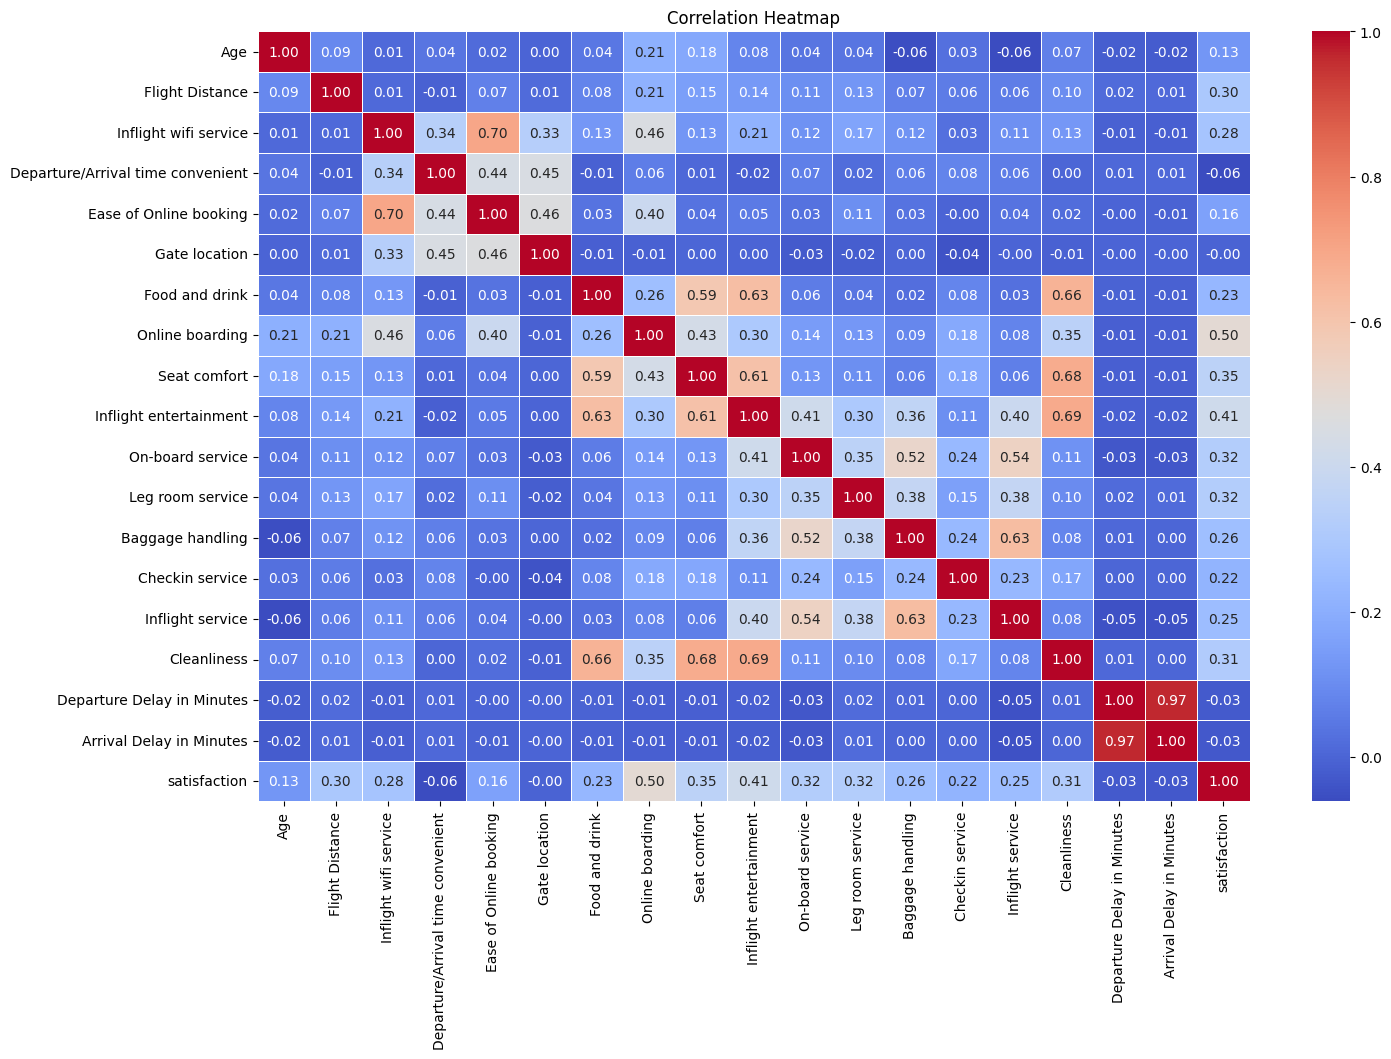

In [ ]:
# Correlation heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

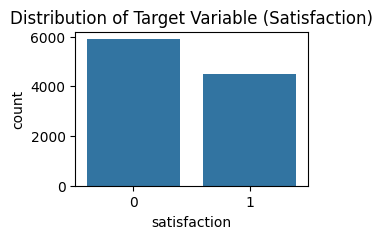

In [ ]:
plt.figure(figsize=(3, 2))
sns.countplot(x='satisfaction', data=train_data)
plt.title("Distribution of Target Variable (Satisfaction)")
plt.show()

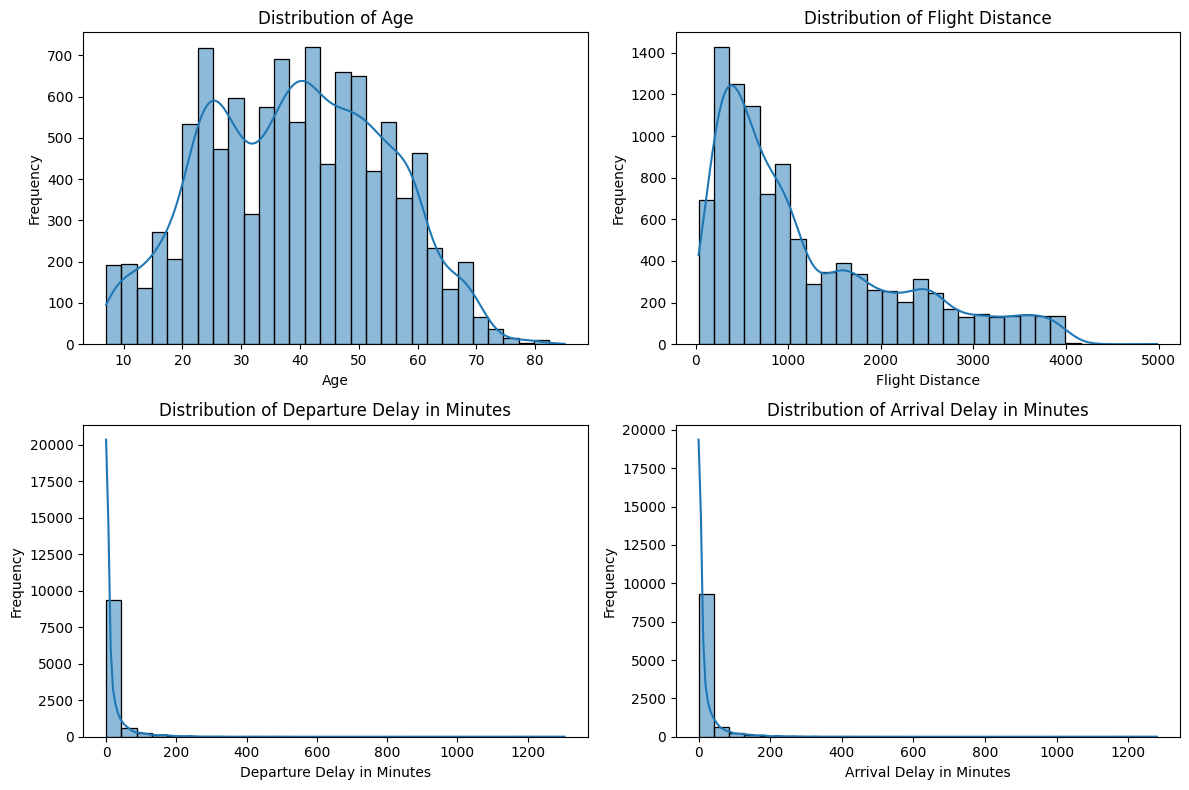

In [ ]:
# Distribution of numerical features
num_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

# Plot distributions of numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(train_data[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

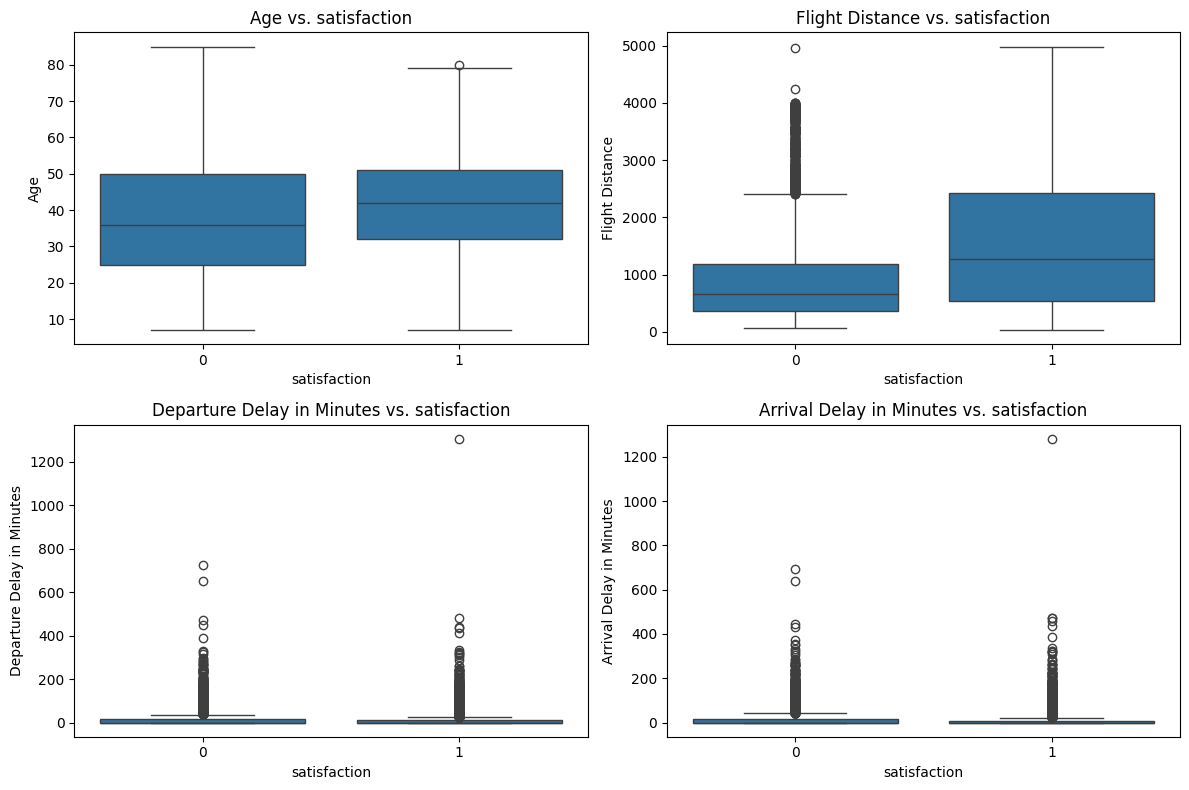

In [ ]:
# List of numerical features
num_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

# Plot distributions of numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='satisfaction', y=feature, data=train_data, dodge=False)
    plt.title(f"{feature} vs. satisfaction")
    plt.xlabel("satisfaction")
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

In [ ]:
combined_data = pd.concat([train_data, test_data], ignore_index=True)

# Encode categorical variables
label_encoder = LabelEncoder()
combined_data['Gender'] = label_encoder.fit_transform(combined_data['Gender'])
combined_data['Customer Type'] = label_encoder.fit_transform(combined_data['Customer Type'])
combined_data['Type of Travel'] = label_encoder.fit_transform(combined_data['Type of Travel'])
combined_data['Class'] = label_encoder.fit_transform(combined_data['Class'])

# Handle missing values (fill with mean)
combined_data.fillna(combined_data.mean(), inplace=True)

# Split combined data back into train and test sets
train_data = combined_data.iloc[:train_data.shape[0], :]
test_data = combined_data.iloc[train_data.shape[0]:, :]

In [ ]:
# Separate features and target for training data
X_train = train_data.drop(columns=['satisfaction'])
y_train = train_data['satisfaction']

# Separate features and target for test data
X_test = test_data.drop(columns=['satisfaction'])
y_test = test_data['satisfaction']

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Dimensionality Reduction

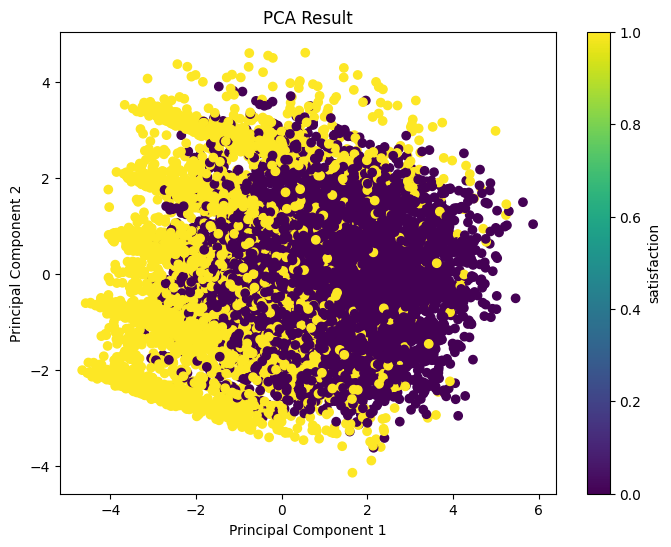

In [ ]:
# PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_train_scaled)

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_train, cmap='viridis')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='satisfaction')
plt.show()


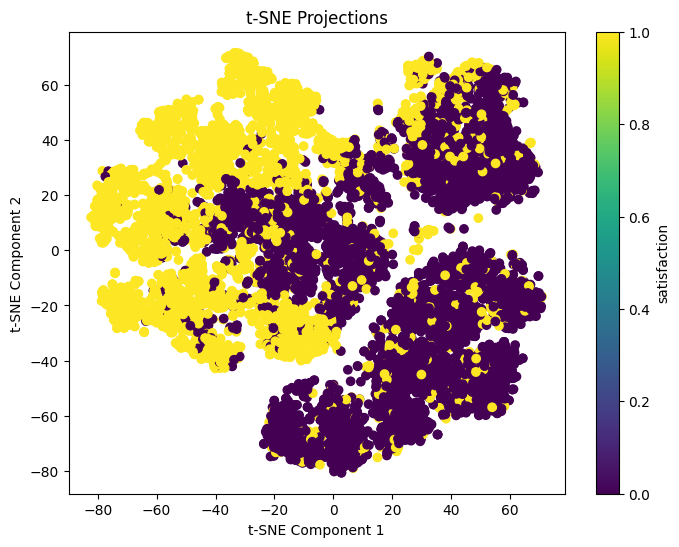

In [ ]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
projections = tsne.fit_transform(X_train_scaled)

# Create scatter plot for t-SNE projections
plt.figure(figsize=(8, 6))
plt.scatter(projections[:, 0], projections[:, 1], c=y_train, cmap='viridis')
plt.title('t-SNE Projections')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='satisfaction')
plt.show()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


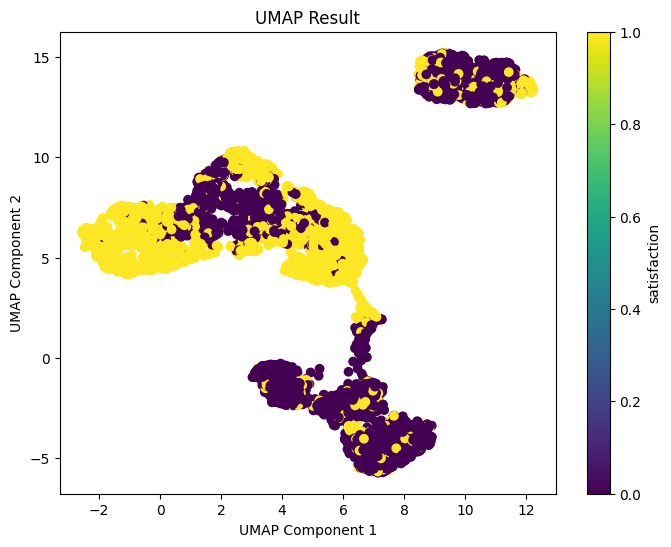

In [ ]:
# UMAP
umap = UMAP(n_components=2, init='random', random_state=42)
umap_result = umap.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y_train, cmap='viridis')
plt.title('UMAP Result')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar(label='satisfaction')
plt.show()

### Feature Selection

In [71]:
rf_classifier = RandomForestClassifier(n_estimators=50, random_state=40)

# Train model without feature selection
rf_classifier.fit(X_train_scaled, y_train)
y_pred = rf_classifier.predict(X_test_scaled)
print("Accuracy without feature selection:", accuracy_score(y_test, y_pred))

cv_scores = cross_val_score(rf_classifier, X_train_scaled, y_train, cv=5)
print("Cross-validation scores without feature selection:", cv_scores)
print("Mean CV accuracy without feature selection:", np.mean(cv_scores))

Accuracy without feature selection: 0.9460916442048517
Cross-validation scores without feature selection: [0.94417709 0.93984601 0.94706449 0.94802695 0.93695861]
Mean CV accuracy without feature selection: 0.9432146294513956


In [72]:
# Select features based on feature importance
sfm = SelectFromModel(rf_classifier, threshold='median')
sfm.fit(X_train_scaled, y_train)
X_train_filtered = sfm.transform(X_train_scaled)
X_test_filtered = sfm.transform(X_test_scaled)

# Train Random Forest Classifier with filtered features
rf_classifier.fit(X_train_filtered, y_train)
y_pred_filtered = rf_classifier.predict(X_test_filtered)
print("Accuracy with filter:", accuracy_score(y_test, y_pred_filtered))

# Evaluate model performance with cross-validation after feature selection
cv_scores_filtered = cross_val_score(rf_classifier, X_train_filtered, y_train, cv=5)
print("Cross-validation scores with feature selection:", cv_scores_filtered)
print("Mean CV accuracy with feature selection:", np.mean(cv_scores_filtered))

Accuracy with filter: 0.9441663457835965
Cross-validation scores with feature selection: [0.94321463 0.94562079 0.93647738 0.94658325 0.93118383]
Mean CV accuracy with feature selection: 0.9406159769008662


In [73]:
# Initialize RFE with Random Forest Classifier as estimator
rfe = RFE(estimator=rf_classifier, n_features_to_select=16, step=1)

# Fit RFE
rfe.fit(X_train_scaled, y_train)

# Filter training and test data using RFE-selected features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

# Train Random Forest Classifier with RFE-selected features
rf_classifier.fit(X_train_rfe, y_train)
y_pred_rfe = rf_classifier.predict(X_test_rfe)
print("Accuracy with Wrapper:", accuracy_score(y_test, y_pred_rfe))

# Evaluate model performance with cross-validation after feature selection (RFE)
cv_scores_rfe = cross_val_score(rf_classifier, X_train_rfe, y_train, cv=5)
print("Cross-validation scores with Wrapper:", cv_scores_rfe)
print("Mean CV accuracy with Wrapper:", np.mean(cv_scores_rfe))

Accuracy with Wrapper: 0.9499422410473624
Cross-validation scores with Wrapper: [0.95043311 0.94417709 0.94658325 0.95524543 0.94177093]
Mean CV accuracy with Wrapper: 0.9476419634263715


## **Refrences**

*  https://plotly.com/python/t-sne-and-umap-projections/

*  https://umap-learn.readthedocs.io/en/latest/basic_usage.html

*   https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
*  



